In [1]:
import os
import sys
import wandb
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'scripts'))

In [2]:
from model import GraphSAGENet
from process_data import DataProcessor
from train import train_epoch_full_graph, evaluate_full_graph

In [3]:
data_path = '../data/firebox_data/FIREbox_z=0.txt'
data_processor = DataProcessor(file_path=data_path)
preliminary_data = data_processor.load_data()

In [4]:
data_processor.create_graph_data(k=5, include_lg_Mstar=True, stratify_bins=10, standardize=False)
data = data_processor.data

In [ ]:
# Mean of non-standardized data
data.x.mean(dim=0)

tensor([ 3.0136e+01,  7.6507e+03,  9.2272e+03,  7.9830e+03,  1.8059e+00,
         1.6276e+00, -2.0496e+00,  5.7960e+00])

In [9]:
num_layers = 2
hidden_channels = 64
mlp_hidden = 128
learning_rate = 0.001
num_epochs = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")
print(f"Data: {data}")
print(f"Train nodes: {data.train_mask.sum()}")
print(f"Test nodes: {data.test_mask.sum()}")

# Initialize model
model = GraphSAGENet(
    in_channels=data.x.size(1),
    hidden_channels=hidden_channels,
    num_layers=num_layers,
    mlp_hidden=mlp_hidden
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f"Model: {model}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")


Using device: cpu
Data: Data(x=[6213, 8], edge_index=[2, 32664], y=[6213, 1], pos=[6213, 3], train_mask=[6213], test_mask=[6213])
Train nodes: 4970
Test nodes: 1243
Model: GraphSAGENet(
  (convs): ModuleList(
    (0): SAGEConv(8, 64, aggr=mean)
    (1): SAGEConv(64, 64, aggr=mean)
  )
  (norms): ModuleList(
    (0-1): 2 x LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (mlp): MLPRegressor(
    (mlp): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)
Number of parameters: 18049


## K-NN

In [10]:
k_values = [4, 8, 12, 16, 20, 24, 28]
all_k_predictions = []
all_k_residuals = []
train_losses = []
val_rmses = []
val_maes = []

for k in k_values:
    data_processor.create_graph_data(k=k, include_lg_Mstar=True, stratify_bins=10, standardize=True)
    data = data_processor.data
    model = GraphSAGENet(
        in_channels=data.x.size(1),
        hidden_channels=hidden_channels,
        num_layers=num_layers,
        mlp_hidden=mlp_hidden
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    best_val_rmse = float('inf')
    train_loss = []
    val_rmse = []
    val_mae = []
    
    for epoch in range(num_epochs):
        train_loss.append(train_epoch_full_graph(model, optimizer, data, device))
        val_rmse.append(evaluate_full_graph(model, data, device)[0])
        val_mae.append(evaluate_full_graph(model, data, device)[1])
    
    train_losses.append(train_loss[-1])
    val_rmses.append(val_rmse[-1])
    val_maes.append(val_mae[-1])
    predictions = model.predict(data, device)
    residuals = predictions - data.y.view(-1).cpu()
    all_k_predictions.append(predictions)
    all_k_residuals.append(residuals)

    if val_rmse[-1] < best_val_rmse:
        best_val_rmse = val_rmse[-1]
    
    print(f'Best validation RMSE for k={k}: {best_val_rmse:.4f}')

Best validation RMSE for k=4: 0.2702
Best validation RMSE for k=8: 0.2435
Best validation RMSE for k=12: 0.2493
Best validation RMSE for k=16: 0.2854
Best validation RMSE for k=20: 0.2288
Best validation RMSE for k=24: 0.2542
Best validation RMSE for k=28: 0.2737


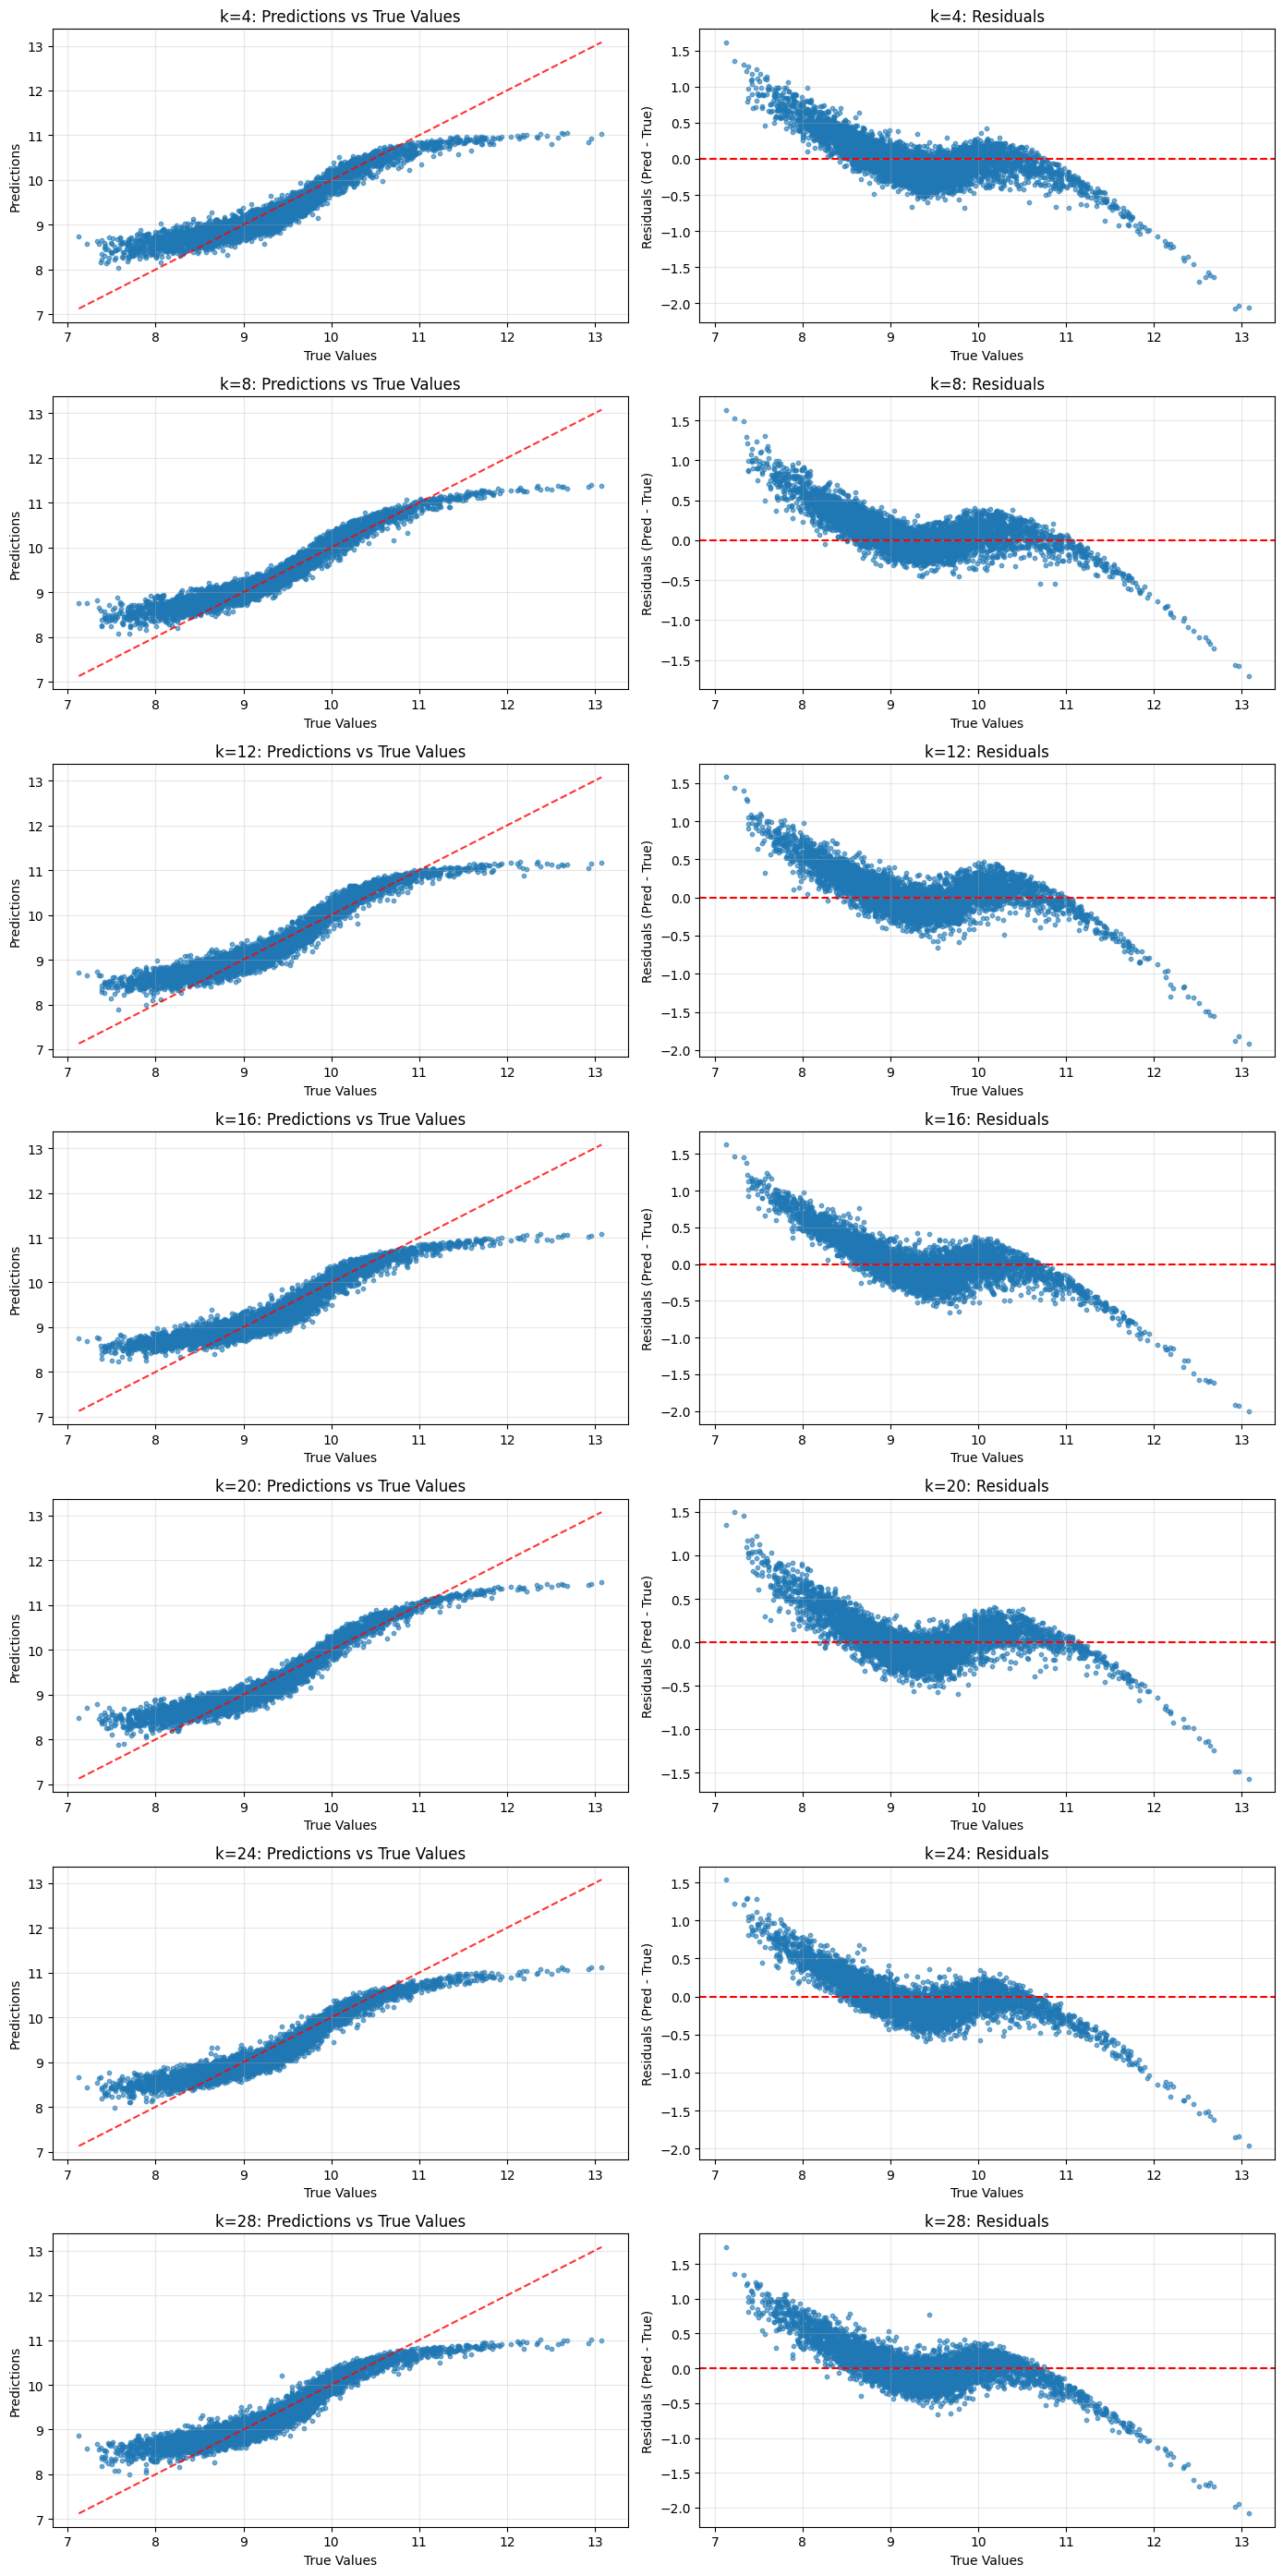

In [11]:
# Create visualization for each k value
all_true_values = data.y.view(-1).cpu()

fig, axes = plt.subplots(7, 2, figsize=(14, 28))

# Assuming you have 7 different k values
k_values = range(1, 8)  # Adjust this based on your actual k values

for i, k in enumerate(k_values):
    # Get predictions and residuals for this k value
    predictions = all_k_predictions[i]  # Adjust indexing based on your data structure
    residuals = all_k_residuals[i]
    true_values = all_true_values
    
    # True vs Predictions plot
    axes[i, 0].scatter(true_values, predictions, alpha=0.6, s=10)
    axes[i, 0].set_xlabel('True Values')
    axes[i, 0].set_ylabel('Predictions')
    axes[i, 0].set_title(f'k={k*4}: Predictions vs True Values')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Add perfect prediction line
    min_val = min(true_values.min(), predictions.min())
    max_val = max(true_values.max(), predictions.max())
    axes[i, 0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    
    # Residuals plot
    axes[i, 1].scatter(true_values, residuals, alpha=0.6, s=10)
    axes[i, 1].axhline(y=0, color='r', linestyle='--')
    axes[i, 1].set_xlabel('True Values')
    axes[i, 1].set_ylabel('Residuals (Pred - True)')
    axes[i, 1].set_title(f'k={k*4}: Residuals')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
